In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import pandas as pd
from src.metrics import add_rolling_metrics

file_path = Path('..') / 'data' / 'panel_aggregate.csv'
if file_path.exists():
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
else:
    print("File not found. Make sure loader.py has run first.")

DataFrame loaded successfully!


In [3]:
# ensure Timestamp column exists
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# drop rows where conversion failed
df = df.dropna(subset=["Timestamp"])

# set as DatetimeIndex
df = df.set_index("Timestamp")

# sort the index
df = df.sort_index()

In [4]:
df = add_rolling_metrics(
    df,
    columns=["THD1", "THD2", "THD3"],
    windows=("5min", "10min", "30min"),
)

print(df.head())

                           Voltage1  Voltage2  Voltage3  Current1  Current2  \
Timestamp                                                                     
2023-10-04 23:55:00-06:00    242.38    241.96    244.06      22.1      17.6   
2023-10-04 23:55:02-06:00    242.36    241.92    244.06      22.1      17.6   
2023-10-04 23:55:04-06:00    242.32    241.90    244.06      22.1      17.5   
2023-10-04 23:55:06-06:00    242.32    241.92    244.06      22.1      17.5   
2023-10-04 23:55:08-06:00    242.34    241.92    244.08      22.1      17.5   

                           Current3  Frequency  Real Power1  Real Power2  \
Timestamp                                                                  
2023-10-04 23:55:00-06:00      13.5     50.054         5260         3700   
2023-10-04 23:55:02-06:00      13.5     50.054         5240         3700   
2023-10-04 23:55:04-06:00      13.5     50.052         5240         3680   
2023-10-04 23:55:06-06:00      13.5     50.050         5240       

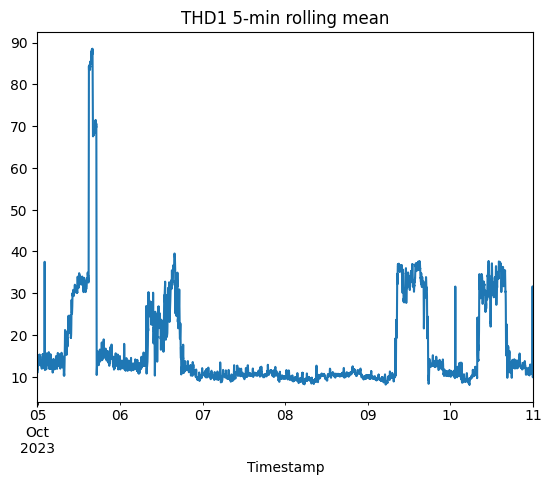

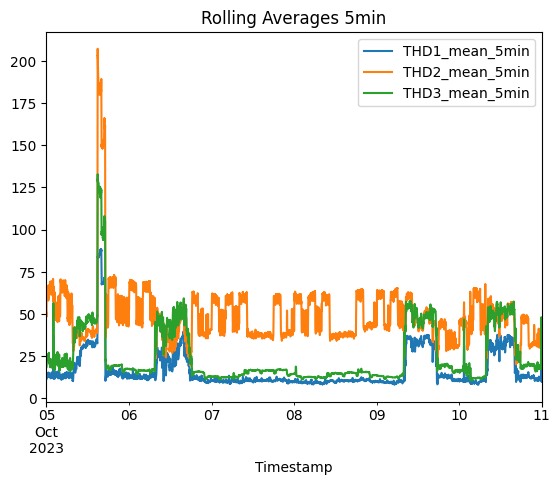

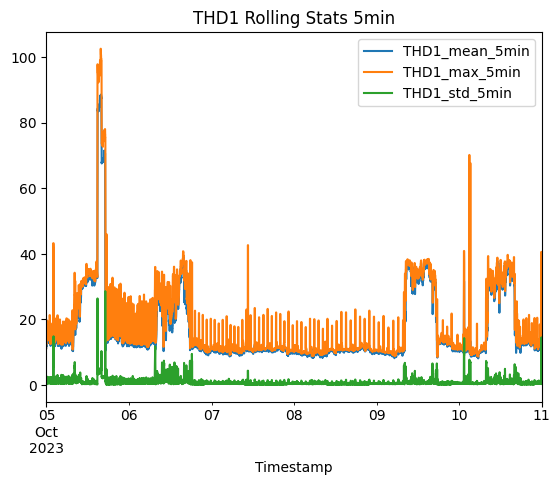

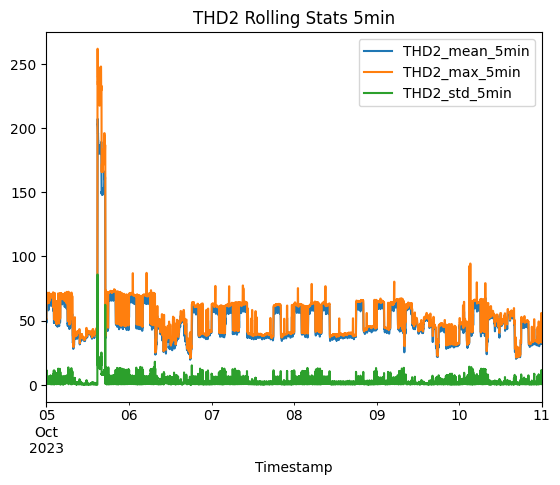

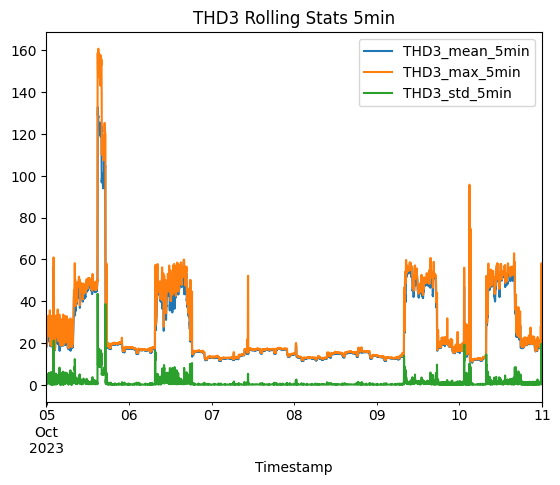

In [5]:
import matplotlib.pyplot as plt

df["THD1_mean_5min"].plot(title="THD1 5-min rolling mean")
plt.show()

df[["THD1_mean_5min", "THD2_mean_5min", "THD3_mean_5min"]].plot()
plt.title("Rolling Averages 5min")
plt.show()

df[["THD1_mean_5min", "THD1_max_5min", "THD1_std_5min"]].plot()
plt.title("THD1 Rolling Stats 5min")
plt.show()

df[["THD2_mean_5min", "THD2_max_5min", "THD2_std_5min"]].plot()
plt.title("THD2 Rolling Stats 5min")
plt.show()

df[["THD3_mean_5min", "THD3_max_5min", "THD3_std_5min"]].plot()
plt.title("THD3 Rolling Stats 5min")
plt.show()


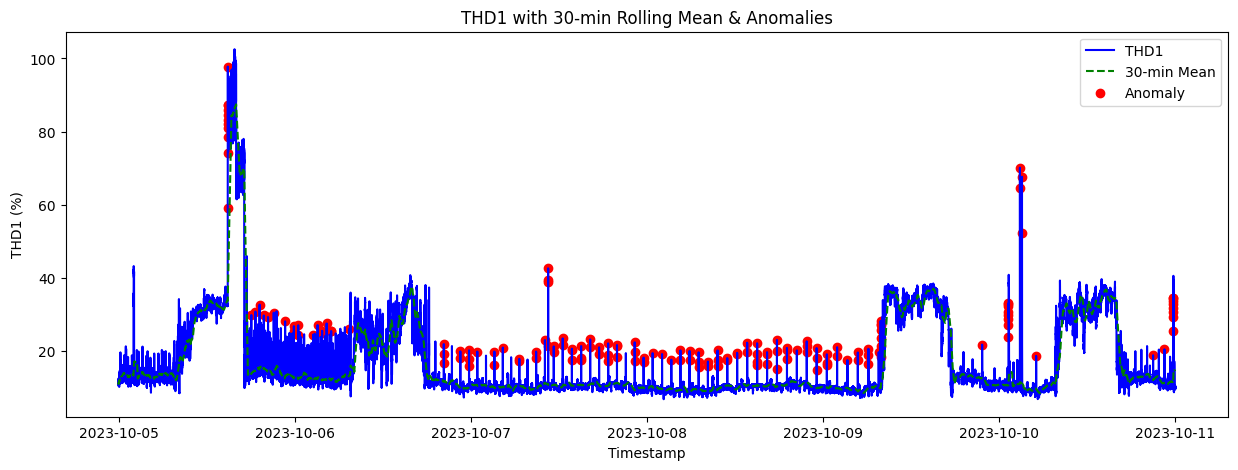

In [6]:
import matplotlib.pyplot as plt

# flag THD as high if it exceeds mean + 10*std (30-min rolling window)
threshold_multiplier = 10

df["THD1_high"] = df["THD1"] > (df["THD1_mean_30min"] + threshold_multiplier * df["THD1_std_30min"])

plt.figure(figsize=(15,5))

# original signal
plt.plot(df.index, df["THD1"], label="THD1", color="blue")

# rolling mean
plt.plot(df.index, df["THD1_mean_30min"], label="30-min Mean", color="green", linestyle="--")

# highlight anomalies
plt.scatter(
    df.index[df["THD1_high"]],
    df["THD1"][df["THD1_high"]],
    color="red",
    label="Anomaly",
    zorder=1
)

plt.title("THD1 with 30-min Rolling Mean & Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("THD1 (%)")
plt.legend()
plt.show()

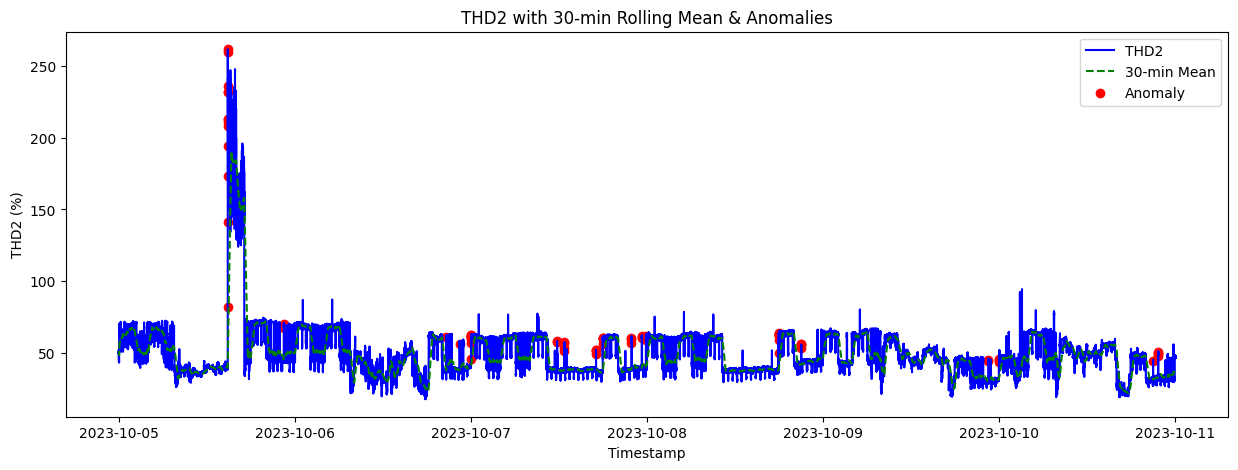

In [7]:
df["THD2_high"] = df["THD2"] > (df["THD2_mean_30min"] + threshold_multiplier * df["THD2_std_30min"])

plt.figure(figsize=(15,5))

# original signal
plt.plot(df.index, df["THD2"], label="THD2", color="blue")

# rolling mean
plt.plot(df.index, df["THD2_mean_30min"], label="30-min Mean", color="green", linestyle="--")

# highlight anomalies
plt.scatter(
    df.index[df["THD2_high"]],
    df["THD2"][df["THD2_high"]],
    color="red",
    label="Anomaly",
    zorder=1
)

plt.title("THD2 with 30-min Rolling Mean & Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("THD2 (%)")
plt.legend()
plt.show()

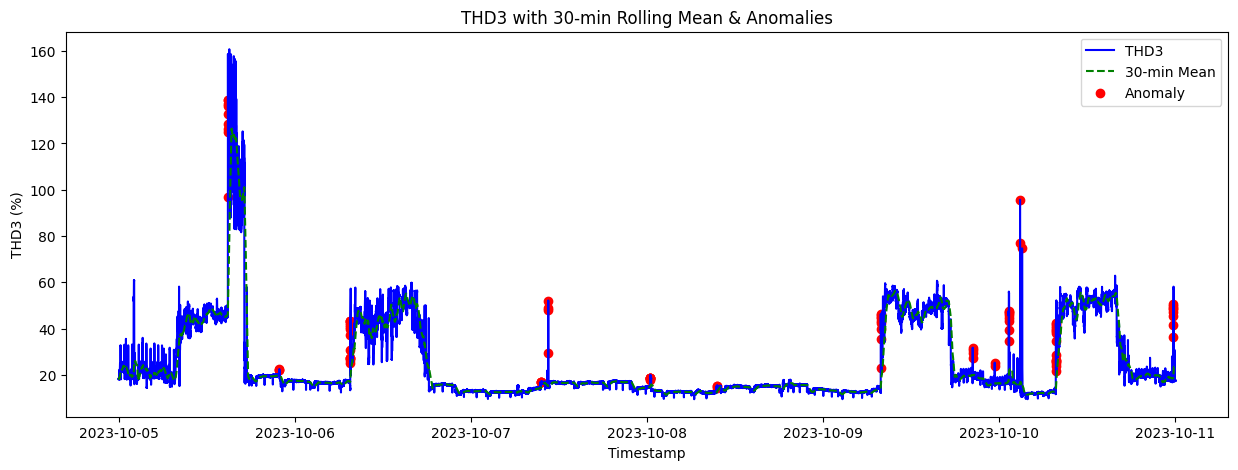

In [8]:
df["THD3_high"] = df["THD3"] > (df["THD3_mean_30min"] + threshold_multiplier * df["THD3_std_30min"])

plt.figure(figsize=(15,5))

# original signal
plt.plot(df.index, df["THD3"], label="THD3", color="blue")

# rolling mean
plt.plot(df.index, df["THD3_mean_30min"], label="30-min Mean", color="green", linestyle="--")

# highlight anomalies
plt.scatter(
    df.index[df["THD3_high"]],
    df["THD3"][df["THD3_high"]],
    color="red",
    label="Anomaly",
    zorder=1
)

plt.title("THD3 with 30-min Rolling Mean & Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("THD3 (%)")
plt.legend()
plt.show()